# EDA FakeNewsNet (Politifact + GossipCop)

Ce notebook réalise une **analyse exploratoire des données (EDA)** en fusionnant 4 fichiers :
- politifact_real.csv
- politifact_fake.csv
- gossipcop_real.csv
- gossipcop_fake.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from urllib.parse import urlparse
import re
from collections import Counter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)

In [3]:
# Chemin racine du projet (adapter si besoin)
ROOT = Path.cwd()

files = {
    "politifact_real": ROOT / "valentine/FakeNewsNet-master/dataset/politifact_real.csv",
    "politifact_fake": ROOT / "valentine/FakeNewsNet-master/dataset/politifact_fake.csv",
    "gossipcop_real": ROOT / "valentine/FakeNewsNet-master/dataset/gossipcop_real.csv",
    "gossipcop_fake": ROOT / "valentine/FakeNewsNet-master/dataset/gossipcop_fake.csv",
}

def load_with_meta(path: Path, key: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    source = key.split("_")[0]      # politifact / gossipcop
    label_str = key.split("_")[1]   # real / fake
    df["source"] = source
    df["label_str"] = label_str
    df["label"] = int(label_str == "fake")  # 1=fake, 0=real
    return df

dfs = [load_with_meta(path, key) for key, path in files.items()]
df = pd.concat(dfs, ignore_index=True)

print(f"Nombre total de lignes : {len(df):,}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.head()

Nombre total de lignes : 23,196
Nombre de colonnes : 7


,id,news_url,title,tweet_ids,source,label_str,label
0,politifact14984,http://www.nfib-sbet.org/,National Federation of Independent Business,967132259869487105\t967164368768196609\t967215618687512581\t967386148468416513\t968234223189610498\t968238354599940096\t9696073313309081...,politifact,real,0
1,politifact12944,http://www.cq.com/doc/newsmakertranscripts-4942265?3,comments in Fayetteville NC,942953459\t8980098198\t16253717352\t16685132501\t18459384142\t20408136207\t22245152650\t76287470559444992\t91736060433928192\t1670130502...,politifact,real,0
2,politifact333,https://web.archive.org/web/20080204072132/http://www.rockymountainnews.com:80/news/2008/feb/02/romney-tells-denver-crowd-he-can-salvage...,"Romney makes pitch, hoping to close deal : Elections : The Rocky Mountain News",NaN,politifact,real,0
3,politifact4358,https://web.archive.org/web/20110811143753/http://www.dems.gov/press/democratic-leaders-say-house-democrats-are-united-against-gop-defau...,Democratic Leaders Say House Democrats Are United Against GOP Default Act,NaN,politifact,real,0
4,politifact779,https://web.archive.org/web/20070820164107/http://www.whitehouse.gov/omb/budget/fy2008/outlook.html,"Budget of the United States Government, FY 2008",89804710374154240\t91270460595109888\t96039619300306944\t106486564980400129\t239664119966470145\t531736791594713089\t975594288800194561\...,politifact,real,0


In [4]:
# Vue globale
display(df.sample(5, random_state=42))
display(df.describe(include="all").T)

print("\nTypes de colonnes:")
display(df.dtypes.to_frame("dtype"))

,id,news_url,title,tweet_ids,source,label_str,label
4291,gossipcop-847761,https://www.msn.com/en-au/entertainment/movies/jk-rowling-sorry-for-killing-off-harry-potter-character/ar-AAwESBV,JK Rowling sorry for killing off Harry Potter character,727217086838231040\t728403130484989955\t728977460835028993\t859447423344803840\t859451989242949632\t859452467347574784\t8594524711895572...,gossipcop,real,0
14922,gossipcop-888170,https://www.yahoo.com/entertainment/chrissy-teigens-dad-hilariously-throws-shade-khloe-kardashian-052815747.html,Chrissy Teigen's dad hilariously throws shade at Khloe Kardashian,NaN,gossipcop,real,0
19868,gossipcop-4848478073,hollywoodlife.com/2018/06/12/selena-gomez-sing-about-justin-bieber-the-weeknd-new-album-heartfelt/,Will Selena Gomez Sing About Justin Bieber Or The Weeknd On Her Upcoming ‘Heartfelt’ Album?,1006748292900933638\t1006748429974982656\t1006748721088827392\t1006753591569330176\t1006753793793380352\t1006755810955759617\t1006761709...,gossipcop,fake,1
12669,gossipcop-843505,https://goop.com/travel/guides/the-goop-fast-food-guide/,The goop Fast Food Guide,852685769156079616\t852686954252705792\t852687380800602112\t852687386349772801\t852687385229787136\t852687390682611712\t8526879974222479...,gossipcop,real,0
12570,gossipcop-907764,https://en.wikipedia.org/wiki/Jersey_Shore:_Family_Vacation,Jersey Shore: Family Vacation,955430721950273536\t955431122997010432\t955431295160602629\t955432179131088896\t955433752662102016\t955433793166323713\t9554349329560002...,gossipcop,real,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,23196,23194,politifact14940,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
news_url,22866,21658,https://www.thewrap.com/this-is-us-everything-we-know-her-rebecca-future-randall-tess-beth-mother/,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,23196,21724,Connecting People Through News,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tweet_ids,21695,21597,950201158445948928\t978452415514136576\t1015659447857885186\t1020177721123536897,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,23196,2,gossipcop,22140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_str,23196,2,real,17441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,23196.0,NaN,NaN,NaN,0.248103,0.431921,0.0,0.0,0.0,0.0,1.0



Types de colonnes:


,dtype
id,str
news_url,str
title,str
tweet_ids,str
source,str
label_str,str
label,int64


In [5]:
# Valeurs manquantes et doublons
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing)

dup_all = df.duplicated().sum()
dup_id = df.duplicated(subset=["id"]).sum() if "id" in df.columns else np.nan
dup_title = df.duplicated(subset=["title"]).sum() if "title" in df.columns else np.nan
print(f"Doublons (lignes complètes) : {dup_all}")
print(f"Doublons sur id : {dup_id}")
print(f"Doublons sur title : {dup_title}")

,missing_count,missing_pct
tweet_ids,1501,6.47
news_url,330,1.42
id,0,0.00
title,0,0.00
source,0,0.00
label_str,0,0.00
label,0,0.00


Doublons (lignes complètes) : 0
Doublons sur id : 2
Doublons sur title : 1472


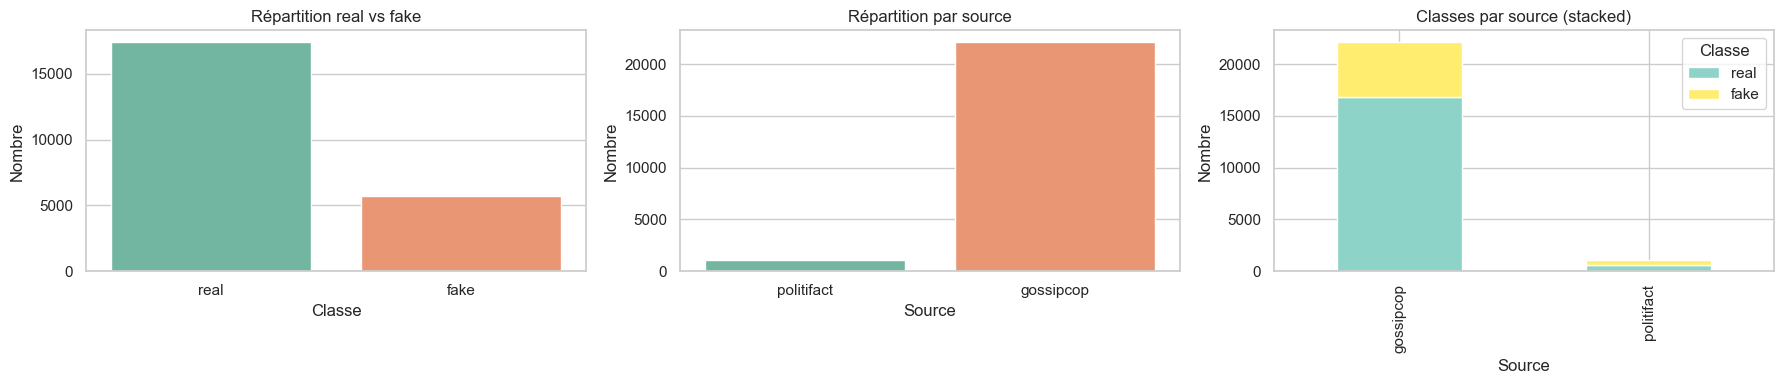

label_str,real,fake
source,,
gossipcop,16817,5323
politifact,624,432


In [10]:
# Répartition des classes et des sources
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="label_str", order=["real", "fake"], hue="label_str", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Répartition real vs fake")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre")

sns.countplot(data=df, x="source", hue="source", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Répartition par source")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Nombre")

ct = pd.crosstab(df["source"], df["label_str"]).reindex(columns=["real", "fake"], fill_value=0)
ct.plot(kind="bar", stacked=True, ax=axes[2], colormap="Set3")
axes[2].set_title("Classes par source (stacked)")
axes[2].set_xlabel("Source")
axes[2].set_ylabel("Nombre")
axes[2].legend(title="Classe")

plt.tight_layout()
plt.show()

display(ct)

,count,mean,std,min,25%,50%,75%,max
title_len_chars,23196.0,68.303328,23.287987,10.0,55.0,68.0,84.0,340.0
title_len_words,23196.0,11.161192,3.977693,1.0,9.0,11.0,14.0,53.0
n_tweet_ids,23196.0,89.021512,488.682874,1.0,11.0,37.0,65.0,29060.0


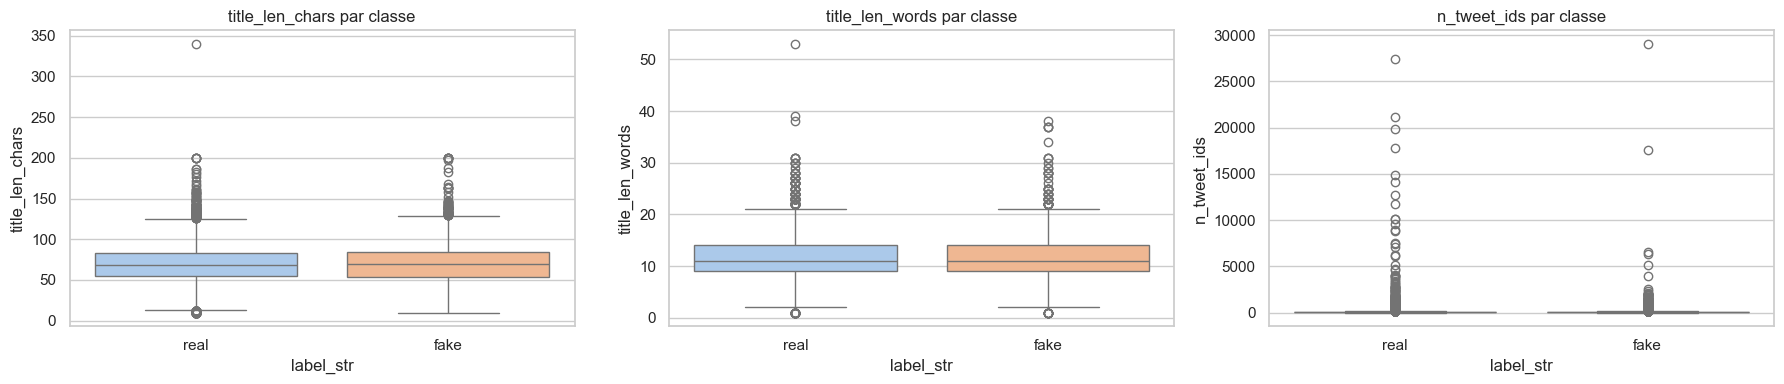

In [11]:
# Features textuelles simples
if "title" in df.columns:
    df["title_len_chars"] = df["title"].fillna("").str.len()
    df["title_len_words"] = df["title"].fillna("").str.split().str.len()

if "tweet_ids" in df.columns:
    # nombre de tweet IDs approximatif (séparation par espaces)
    df["n_tweet_ids"] = (
        df["tweet_ids"].fillna("").astype(str).str.strip().str.split(r"\s+").str.len()
    )

num_cols = [c for c in ["title_len_chars", "title_len_words", "n_tweet_ids"] if c in df.columns]
display(df[num_cols].describe().T)

if num_cols:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))
    if len(num_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, num_cols):
        sns.boxplot(data=df, x="label_str", y=col, order=["real", "fake"], hue="label_str", dodge=False, ax=ax, palette="pastel", legend=False)
        ax.set_title(f"{col} par classe")

    plt.tight_layout()
    plt.show()

,count
domain,
people.com,1786
dailymail.co.uk,964
en.wikipedia.org,741
usmagazine.com,709
etonline.com,666
longroom.com,562
hollywoodlife.com,524
usatoday.com,332
,330


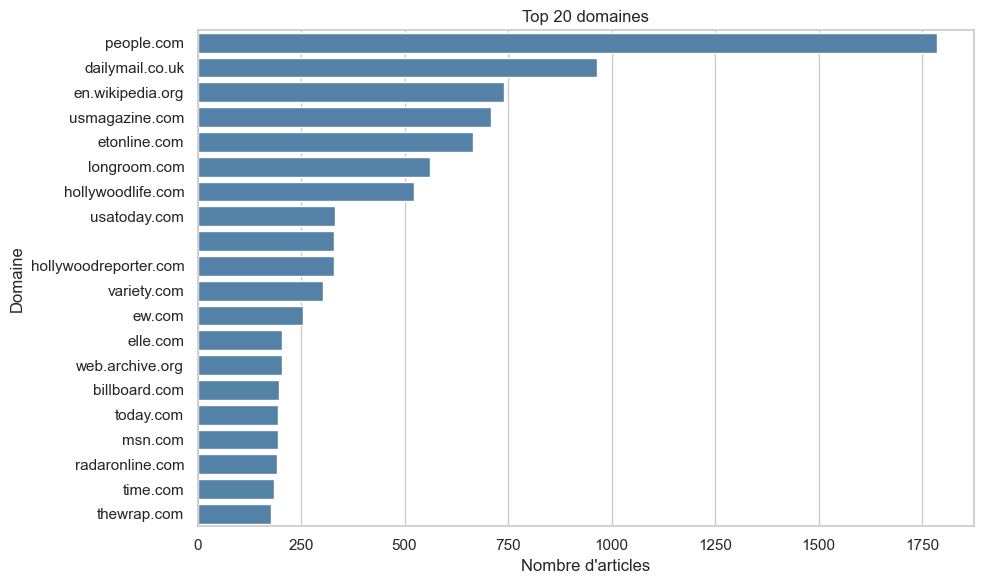

In [12]:
# Analyse des domaines d'URL
def extract_domain(url: str) -> str:
    if pd.isna(url):
        return ""
    url = str(url).strip()
    if not url.startswith(("http://", "https://")):
        url = "http://" + url
    try:
        netloc = urlparse(url).netloc.lower()
        return netloc.replace("www.", "")
    except Exception:
        return ""

df["domain"] = df["news_url"].apply(extract_domain)

top_domains = df["domain"].value_counts().head(20)
display(top_domains.to_frame("count"))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_domains.values, y=top_domains.index, color="steelblue")
plt.title("Top 20 domaines")
plt.xlabel("Nombre d'articles")
plt.ylabel("Domaine")
plt.tight_layout()
plt.show()

,word,count
0,her,1843
1,after,1023
2,new,824
3,from,751
4,about,733
5,his,693
6,how,666
7,kardashian,628
8,season,626
9,she,600


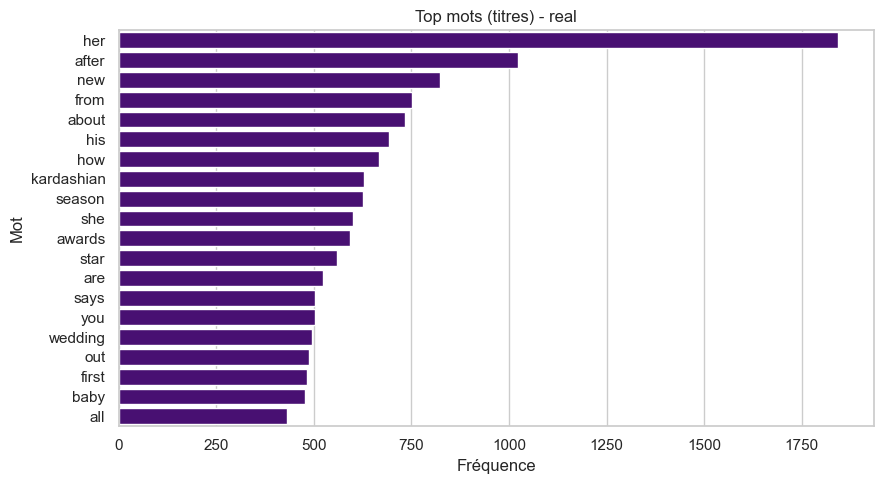

,word,count
0,jennifer,482
1,her,458
2,kardashian,441
3,brad,413
4,pitt,373
5,jenner,361
6,after,354
7,justin,353
8,about,310
9,not,299


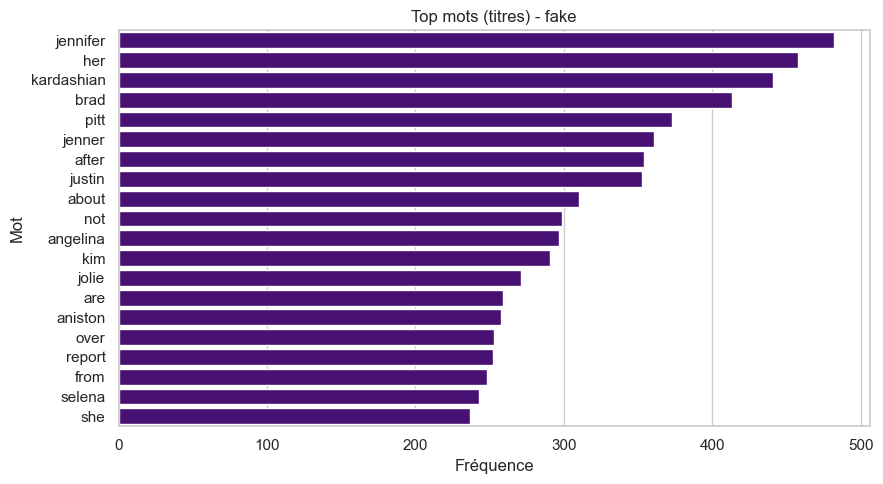

In [13]:
# Mots fréquents dans les titres
stopwords_fr_en = {
    "the", "a", "an", "of", "to", "and", "in", "for", "on", "with", "at",
    "de", "la", "le", "les", "des", "du", "et", "en", "un", "une"
}

def top_words(series: pd.Series, n=20):
    text = " ".join(series.fillna("").astype(str).str.lower())
    tokens = re.findall(r"[a-zà-ÿ']{3,}", text)
    tokens = [t for t in tokens if t not in stopwords_fr_en]
    return Counter(tokens).most_common(n)

for cls in ["real", "fake"]:
    words = top_words(df.loc[df["label_str"] == cls, "title"], n=20)
    words_df = pd.DataFrame(words, columns=["word", "count"] )
    display(words_df.head(20))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=words_df, x="count", y="word", color="indigo")
    plt.title(f"Top mots (titres) - {cls}")
    plt.xlabel("Fréquence")
    plt.ylabel("Mot")
    plt.tight_layout()
    plt.show()

## Prochaines étapes recommandées

1. Nettoyer les doublons sur `id` et vérifier les `title` quasi-identiques.
2. Créer des features supplémentaires (n-grams, TF-IDF, présence de ponctuation forte, etc.).
3. Split train/valid/test stratifié par `label` et éventuellement par `source`.
4. Entraîner un baseline (LogReg / LinearSVC) et comparer les performances intra-source vs cross-source.